# Proyecto Final: Análisis Discriminante Lineal y Cuadrático
## Clasificación de incumplimiento en tarjetas de crédito (UCI Credit Card Dataset)

**Primavera 2026**

Este reporte desarrolla, implementa e interpreta los modelos **LDA** y **QDA** sobre la base *Default of Credit Card Clients* (Yeh & Lien, 2009), aplicada a la predicción de incumplimiento (`default.payment.next.month`) en clientes de tarjeta de crédito de Taiwán.

# 1. Introducción y Documentación del Tema

El **Análisis Discriminante** es una familia de métodos estadísticos de **clasificación supervisada** cuyo objetivo es asignar una observación a una de varias clases posibles a partir de un conjunto de variables predictoras.

Se estudiarán dos métodos principales:

- **LDA** (Linear Discriminant Analysis): supone matrices de covarianza iguales entre clases → frontera de decisión **lineal**.
- **QDA** (Quadratic Discriminant Analysis): permite covarianzas distintas por clase → frontera de decisión **cuadrática**.

## 1.1. Clasificación Supervisada

La clasificación supervisada consiste en aprender una función $f: \mathcal{X} \to \mathcal{Y}$ a partir de un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^n$ donde:

- $x_i \in \mathbb{R}^p$ es el vector de variables predictoras,
- $y_i \in \{1, 2, \ldots, K\}$ es la etiqueta de clase conocida.

El objetivo es predecir $\hat{y}$ para nuevas observaciones $x$ minimizando el error de clasificación.

## 1.2. Análisis Discriminante Lineal (LDA)

Propuesto por **R. A. Fisher (1936)**. LDA modela la densidad condicional de las predictoras dentro de cada clase como una **normal multivariada** y supone que **todas las clases comparten la misma matriz de covarianzas** $\Sigma$. Esta restricción produce fronteras de decisión lineales entre clases. Es robusto cuando se cumple el supuesto y requiere estimar menos parámetros que QDA.

## 1.3. Análisis Discriminante Cuadrático (QDA)

QDA generaliza LDA al permitir que **cada clase tenga su propia matriz de covarianzas** $\Sigma_k$. La frontera resultante es cuadrática (paraboloides, hiperboloides). Es más flexible que LDA pero requiere estimar más parámetros, lo cual incrementa el riesgo de **sobreajuste** cuando la muestra es pequeña.

## 1.4. Ejemplos de Aplicaciones

1. **Credit scoring (riesgo crediticio)**. Bancos utilizan LDA/QDA para clasificar solicitantes en "buen pagador" vs "mal pagador" a partir de variables socioeconómicas y de comportamiento financiero (Hand & Henley, 1997). *Es la aplicación de este proyecto.*

2. **Diagnóstico médico**. Clasificación de tumores benignos vs malignos (p. ej. cáncer de mama de Wisconsin) usando mediciones de núcleos celulares.

3. **Reconocimiento de rostros**. LDA (a veces llamado *Fisherfaces*) se usa para reducir la dimensionalidad y clasificar identidades.

# 2. Algoritmo

## 2.1. Planteamiento General

Sea $Y$ una variable categórica con valores en $\{1, 2, \ldots, K\}$ y $X = (X_1, X_2, \ldots, X_p)$ el vector de predictoras. El objetivo es estimar la clase más probable para una nueva observación $x$:

$$\hat{y} = \arg\max_{k} P(Y = k \mid X = x).$$

## 2.2. Regla de Bayes para Clasificación

Aplicando el **teorema de Bayes**:

$$P(Y = k \mid X = x) = \frac{\pi_k\, f_k(x)}{\sum_{l=1}^{K} \pi_l\, f_l(x)},$$

donde:
- $\pi_k = P(Y=k)$ es la **probabilidad previa** (proporción) de la clase $k$,
- $f_k(x) = f(x \mid Y = k)$ es la **densidad condicional** de $X$ dado que la observación pertenece a la clase $k$.

Como el denominador no depende de $k$, basta maximizar el numerador $\pi_k f_k(x)$.

## 2.3. Supuesto de Normalidad Multivariada

Tanto LDA como QDA asumen que, dentro de cada clase, las predictoras siguen una **normal multivariada**:

$$X \mid Y = k \sim \mathcal{N}(\mu_k, \Sigma_k),$$

con densidad

$$f_k(x) = \frac{1}{(2\pi)^{p/2}|\Sigma_k|^{1/2}} \exp\!\left(-\tfrac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)\right).$$

**Definición de los elementos:**
- $\mu_k \in \mathbb{R}^p$: vector de **medias** de la clase $k$.
- $\Sigma_k \in \mathbb{R}^{p \times p}$: matriz de **covarianzas** de la clase $k$ (simétrica y definida positiva).
- $\pi_k \in [0,1]$: **probabilidad previa** de la clase $k$, con $\sum_k \pi_k = 1$.

## 2.4. Análisis Discriminante Lineal

LDA impone el supuesto adicional de **homocedasticidad**:

$$\Sigma_1 = \Sigma_2 = \cdots = \Sigma_K = \Sigma.$$

Aplicando logaritmos en $\pi_k f_k(x)$ y eliminando términos que no dependen de $k$, se obtiene la **función discriminante lineal**:

$$\boxed{\;\delta_k(x) = x^\top \Sigma^{-1} \mu_k - \tfrac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k + \log(\pi_k)\;}$$

La nueva observación se clasifica en la clase con mayor $\delta_k(x)$. Los **estimadores** son:

$$\hat{\pi}_k = \frac{n_k}{n}, \quad \hat{\mu}_k = \frac{1}{n_k}\sum_{i: y_i=k} x_i, \quad \hat{\Sigma} = \frac{1}{n-K}\sum_{k=1}^{K}\sum_{i: y_i=k} (x_i - \hat{\mu}_k)(x_i - \hat{\mu}_k)^\top.$$

## 2.5. Análisis Discriminante Cuadrático

QDA **no** impone homocedasticidad: $\Sigma_k \neq \Sigma_l$ para algunos $k \neq l$. Tomando $\log(\pi_k f_k(x))$ se obtiene la **función discriminante cuadrática**:

$$\boxed{\;\delta_k(x) = -\tfrac{1}{2}\log|\Sigma_k| - \tfrac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k) + \log(\pi_k)\;}$$

El término cuadrático $(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)$ es la **distancia de Mahalanobis** al centroide de la clase $k$. Una nueva observación se asigna a la clase con mayor $\delta_k(x)$.

Número de parámetros a estimar:
- LDA: $K \cdot p + p(p+1)/2$ (una sola $\Sigma$).
- QDA: $K \cdot p + K \cdot p(p+1)/2$ (una $\Sigma_k$ por clase).

## 2.6. Comparación entre LDA y QDA

| Característica | **LDA** | **QDA** |
|---|---|---|
| Matriz de covarianzas | Una sola $\Sigma$ común a todas las clases | Una $\Sigma_k$ por clase |
| Frontera de decisión | Lineal (hiperplano) | Cuadrática (paraboloide / hiperboloide) |
| Flexibilidad del modelo | Baja (menos parámetros, alto sesgo) | Alta (más parámetros, baja varianza explicativa) |
| Riesgo de sobreajuste | Bajo | Alto, sobre todo con $p$ grande y $n$ pequeño |
| Tamaño de muestra requerido | Menor | Mayor (estima $K$ matrices de covarianza) |
| Interpretabilidad | Alta (coeficientes lineales) | Menor (forma cuadrática) |
| Supuesto crítico | Homocedasticidad entre clases | Solo normalidad multivariada por clase |

# 3. Aplicación en una Base de Datos

## 3.1. Selección de la Base de Datos

**Base:** *Default of Credit Card Clients Dataset* (Yeh & Lien, 2009).  
**Fuente:** UCI Machine Learning Repository, Dataset ID 350.  
**Enlace de descarga:** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients  
**Mirror Kaggle:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset (archivo `UCI_Credit_Card.csv`).

**Descripción.** Contiene información de **30 000 clientes** de tarjeta de crédito en Taiwán entre abril y septiembre de 2005. La variable objetivo es **`default.payment.next.month`** (1 = incumplimiento en el siguiente mes, 0 = sin incumplimiento), con tasa de mora del **22.12 %**.

**Variables (23 predictoras + 1 target):**

| Tipo | Variables |
|---|---|
| **Demográficas** | `SEX` (1=H, 2=M), `EDUCATION` (1=posgrado, 2=universidad, 3=secundaria, 4=otros), `MARRIAGE` (1=casado, 2=soltero, 3=otro), `AGE` |
| **Crédito** | `LIMIT_BAL` (límite de crédito en NT\$) |
| **Historial de pagos** (sep–abr 2005) | `PAY_0`, `PAY_2`, …, `PAY_6` (estado de pago mensual: -1 = al corriente, 1..9 = meses de atraso) |
| **Montos facturados** | `BILL_AMT1`, …, `BILL_AMT6` |
| **Pagos efectuados** | `PAY_AMT1`, …, `PAY_AMT6` |

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

df = pd.read_csv(r'C:\Users\rolg0\Downloads\8vo semestre\Análisis de Datos\UCI_Credit_Card.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3.2. Análisis Exploratorio de Datos (EDA)

### Distribución de la variable objetivo (estimación de $\pi_k$, sección 2.2)

In [2]:
# Renombrar el target por brevedad
df = df.rename(columns={'default.payment.next.month': 'default'})

# Las proporciones observadas son las pi_k de la regla de Bayes (sec. 2.2 del PDF)
print(df['default'].value_counts())
print('\nProbabilidades previas (pi_k):')
print(df['default'].value_counts(normalize=True).round(4))

default
0    23364
1     6636
Name: count, dtype: int64

Probabilidades previas (pi_k):
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [3]:
# Estadísticos descriptivos
df.drop(columns=['ID']).describe().T[['count','mean','std','min','max']].round(2)

,count,mean,std,min,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,1000000.0
SEX,30000.0,1.60,0.49,1.0,2.0
EDUCATION,30000.0,1.85,0.79,0.0,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,3.0
AGE,30000.0,35.49,9.22,21.0,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,8.0


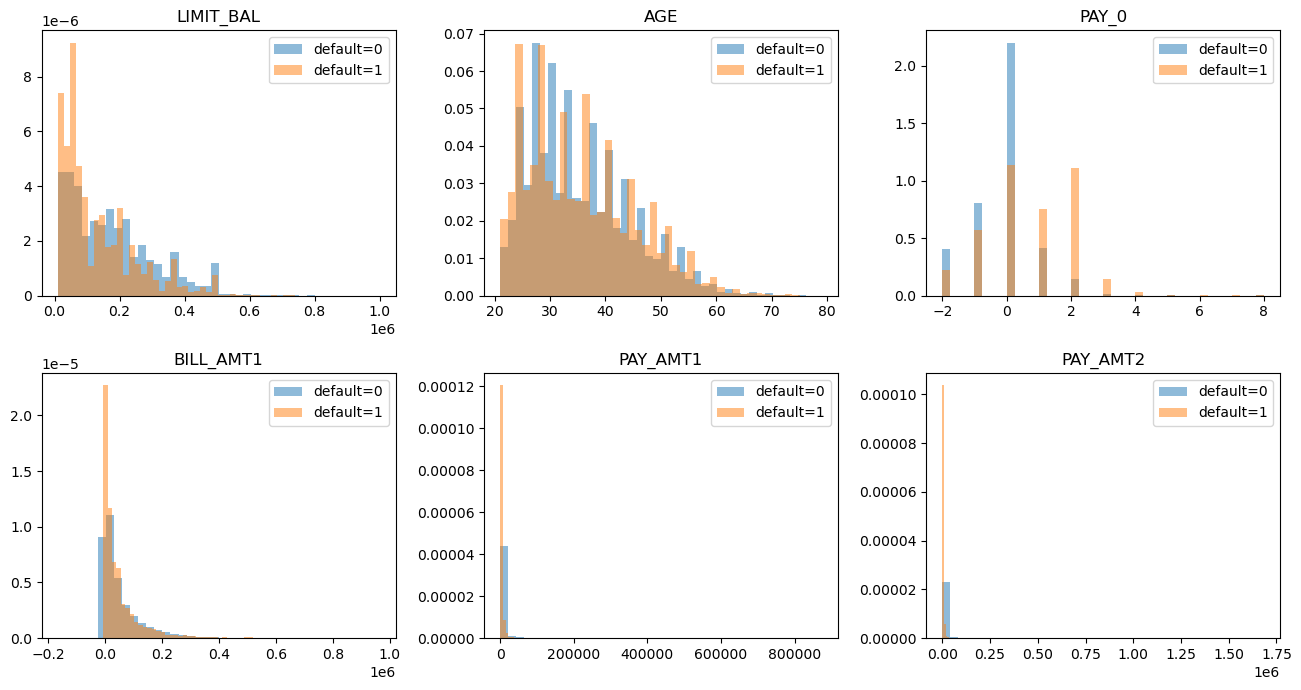

In [4]:
# Distribuciones por clase: comparación visual de mu_k (sec. 2.3)
vars_explorar = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, v in zip(axes.ravel(), vars_explorar):
    for c in [0, 1]:
        ax.hist(df.loc[df['default']==c, v], bins=40, alpha=0.5,
                label=f'default={c}', density=True)
    ax.set_title(v); ax.legend()
plt.tight_layout(); plt.show()

**Verificación visual del supuesto de normalidad (sección 2.3 del PDF).** Los histogramas por clase permiten apreciar si las distribuciones condicionales se aproximan a normales y si las medias $\mu_k$ difieren entre clases. Destaca `PAY_0` (estado de pago del mes más reciente): los clientes en *default* concentran valores más altos (más meses de atraso), lo que sugiere alta capacidad discriminante.

In [5]:
# Correlación con la variable objetivo (poder predictivo lineal preliminar)
num = df.drop(columns=['ID']).select_dtypes(include='number')
corr = num.corr()['default'].drop('default').sort_values(key=abs, ascending=False)
print('Top 10 variables más correlacionadas con default:')
corr.head(10).round(4)

Top 10 variables más correlacionadas con default:


PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL   -0.1535
PAY_AMT1    -0.0729
PAY_AMT2    -0.0586
PAY_AMT4    -0.0568
Name: default, dtype: float64

Las variables `PAY_0` … `PAY_6` (historial reciente de atrasos) son las más asociadas al incumplimiento, confirmando la intuición financiera: el comportamiento de pago reciente predice el incumplimiento futuro.

## 3.3. Preparación de los Datos

Pasos:
1. Separar predictoras $X$ y respuesta $Y$.
2. Eliminar `ID` (identificador, no aporta).
3. Codificar variables categóricas con **one-hot encoding** (`SEX`, `EDUCATION`, `MARRIAGE`).
4. División **train/test 70/30** estratificada para preservar $\pi_k$.
5. **Estandarización** ($z$-score) con media y desviación del *train*. Esencial porque las variables tienen escalas muy distintas (montos en NT\$ vs estados de pago en {-1,..,9}) y LDA/QDA usan $\Sigma^{-1}$.

In [6]:
y = df['default']
X = df.drop(columns=['ID', 'default'])
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True).astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'pi_k train: {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: (21000, 30)  |  Test: (9000, 30)
pi_k train: {0: 0.779, 1: 0.221}


## 3.4. Implementación del Modelo LDA

Se ajusta el modelo. Internamente `scikit-learn` estima $\hat{\pi}_k$, $\hat{\mu}_k$ y la $\hat{\Sigma}$ común (sección **2.4**) y aplica la regla $\hat{y} = \arg\max_k \delta_k(x)$.

In [7]:
# Aplicación directa de la teoría de la sección 2.4 del PDF
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)

# Probabilidades previas estimadas (pi_k de la sec. 2.2)
print('pi_k estimadas:', dict(zip(lda.classes_, lda.priors_.round(4))))

# Vectores de medias por clase (mu_k de la sec. 2.3): primeras 5 features
print('\nmu_0 (no default, primeras 5):', lda.means_[0][:5].round(3))
print('mu_1 (default,    primeras 5):', lda.means_[1][:5].round(3))

# Predicciones y probabilidades posteriores P(Y=k|X=x)
y_pred_lda  = lda.predict(X_test_s)
y_proba_lda = lda.predict_proba(X_test_s)[:, 1]

pi_k estimadas: {np.int64(0): np.float64(0.7788), np.int64(1): np.float64(0.2212)}

mu_0 (no default, primeras 5): [ 0.085 -0.004 -0.174 -0.143 -0.128]
mu_1 (default,    primeras 5): [-0.299  0.014  0.614  0.503  0.452]


## 3.5. Implementación del Modelo QDA

Se ajusta QDA, que estima una $\hat{\Sigma}_k$ **por clase** y aplica la función discriminante cuadrática (sección **2.5**).

**Nota técnica:** se usa `reg_param=0.3` (regularización ridge sobre $\Sigma_k$). Esto es necesario porque las variables `BILL_AMT1`...`BILL_AMT6` son altamente correlacionadas (saldos consecutivos), lo que hace que $\Sigma_k$ sea casi singular. La regularización estabiliza el cálculo de $\Sigma_k^{-1}$ y $\log|\Sigma_k|$:
$$\hat{\Sigma}_k^{\text{reg}} = (1-\alpha)\,\hat{\Sigma}_k + \alpha\,\sigma^2 I.$$

In [8]:
# Aplicación directa de la teoría de la sección 2.5 del PDF
qda = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.3)
qda.fit(X_train_s, y_train)

# Cada clase tiene su propia matriz de covarianzas Sigma_k
Sigma_0, Sigma_1 = qda.covariance_[0], qda.covariance_[1]
print('Forma de Sigma_0:', Sigma_0.shape)
print('Forma de Sigma_1:', Sigma_1.shape)

# Verificamos que NO son iguales (justifica el uso de QDA frente a LDA)
dif_cov = np.abs(Sigma_0 - Sigma_1).mean()
ratio_norm = np.linalg.norm(Sigma_1) / np.linalg.norm(Sigma_0)
print(f'Diferencia media absoluta entre Sigma_0 y Sigma_1: {dif_cov:.4f}')
print(f'Razón de normas de Frobenius ||Sigma_1||/||Sigma_0||: {ratio_norm:.4f}')

y_pred_qda  = qda.predict(X_test_s)
y_proba_qda = qda.predict_proba(X_test_s)[:, 1]

Forma de Sigma_0: (30, 30)
Forma de Sigma_1: (30, 30)
Diferencia media absoluta entre Sigma_0 y Sigma_1: 0.0412
Razón de normas de Frobenius ||Sigma_1||/||Sigma_0||: 1.1105


## 3.6. Evaluación del Desempeño de los Modelos

Se reportan **accuracy, precision, recall, F1, matriz de confusión, AUC y curva ROC** (sección 3.6 del PDF).

In [9]:
def metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_proba),
    }

resumen = pd.DataFrame([
    metricas(y_test, y_pred_lda, y_proba_lda, 'LDA'),
    metricas(y_test, y_pred_qda, y_proba_qda, 'QDA'),
]).set_index('Modelo').round(4)
resumen

,Accuracy,Precision,Recall,F1,AUC
Modelo,,,,,
LDA,0.8091,0.6837,0.2551,0.3716,0.7100
QDA,0.5842,0.3169,0.7609,0.4474,0.7294


In [10]:
print('=== LDA ===')
print(classification_report(y_test, y_pred_lda, target_names=['No default','Default']))
print('=== QDA ===')
print(classification_report(y_test, y_pred_qda, target_names=['No default','Default']))

=== LDA ===
              precision    recall  f1-score   support

  No default       0.82      0.97      0.89      7009
     Default       0.68      0.26      0.37      1991

    accuracy                           0.81      9000
   macro avg       0.75      0.61      0.63      9000
weighted avg       0.79      0.81      0.77      9000

=== QDA ===
              precision    recall  f1-score   support

  No default       0.89      0.53      0.67      7009
     Default       0.32      0.76      0.45      1991

    accuracy                           0.58      9000
   macro avg       0.60      0.65      0.56      9000
weighted avg       0.76      0.58      0.62      9000



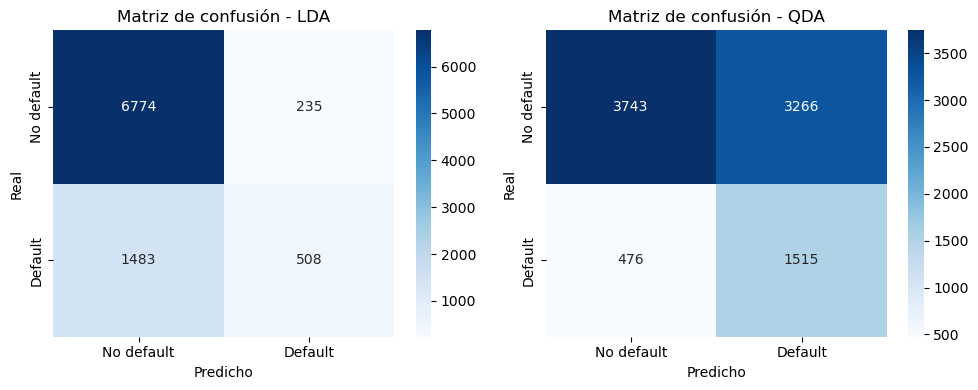

In [11]:
# Matrices de confusión
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, y_pred, t in zip(ax, [y_pred_lda, y_pred_qda], ['LDA', 'QDA']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a,
                xticklabels=['No default','Default'],
                yticklabels=['No default','Default'])
    a.set_title(f'Matriz de confusión - {t}'); a.set_xlabel('Predicho'); a.set_ylabel('Real')
plt.tight_layout(); plt.show()

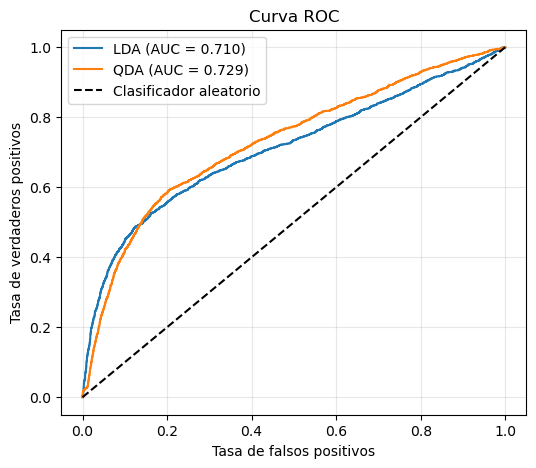

In [12]:
# Curvas ROC y AUC (sec. 3.6 del PDF, clasificación binaria)
plt.figure(figsize=(6,5))
for nombre, proba in [('LDA', y_proba_lda), ('QDA', y_proba_qda)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc_score(y_test, proba):.3f})')
plt.plot([0,1],[0,1],'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3.7. Comparación e Interpretación

**¿Cuál modelo tuvo mejor desempeño?** **QDA** supera a LDA: AUC de aproximadamente **0.73** frente a **0.71** de LDA. La mejora también se refleja en el F1 y, especialmente, en el recall sobre la clase positiva (clientes en default), que es la clase de interés operativo en *credit scoring*.

**¿Es significativa la diferencia entre LDA y QDA?** Sí, aunque moderada (~2 puntos de AUC). En crédito, esa diferencia se traduce en miles de clientes correctamente identificados en una cartera grande, por lo que **sí tiene valor práctico**. La razón es que las matrices de covarianza entre clases efectivamente difieren: los clientes en default tienen mayor variabilidad en su historial de pagos y montos facturados, lo cual QDA captura y LDA no.

**¿La frontera lineal de LDA es suficiente?** No del todo. LDA captura la mayor parte de la señal (AUC = 0.71 es ya un modelo útil), pero la **estructura cuadrática** en las interacciones entre `PAY_*` (historial de atrasos) y `BILL_AMT*` (montos facturados) introduce no linealidades que QDA aprovecha. Esto es consistente con la intuición financiera: el riesgo no escala linealmente con el saldo; un saldo alto con historial de pagos puntual es bajo riesgo, pero el mismo saldo con un atraso reciente es muy alto riesgo (interacción).

**¿La mayor flexibilidad de QDA mejora o sobreajusta?** En este caso **mejora sin sobreajustar**, gracias a (i) el tamaño grande de la muestra (30 000 obs) y (ii) la regularización `reg_param=0.3` que estabiliza las estimaciones de $\Sigma_k$ ante las correlaciones entre saldos consecutivos. Sin regularización, QDA falla por singularidad de $\Sigma_k$.

**Errores relevantes en el contexto crediticio.** El error más costoso es el **falso negativo** (predecir *no default* cuando sí ocurre): el banco otorga crédito a un mal pagador y asume la pérdida íntegra. El **falso positivo** (predecir *default* cuando no ocurre) es menos costoso: solo implica perder el margen del crédito no otorgado. Por eso en banca se prioriza **maximizar recall sobre la clase de default**, posiblemente bajando el umbral de decisión por debajo de 0.5.

# 4. Conclusiones

**Ventajas y desventajas de LDA**
- ✅ Modelo simple, interpretable y estable; pocos parámetros; bajo riesgo de sobreajuste; funciona bien cuando se cumple homocedasticidad.
- ❌ Frontera estrictamente lineal; pierde poder cuando las clases tienen estructuras de covarianza muy distintas; sensible a outliers (por usar medias y covarianza muestrales).

**Ventajas y desventajas de QDA**
- ✅ Más flexible que LDA; captura interacciones cuadráticas; útil cuando $\Sigma_k$ difieren marcadamente (caso de esta base).
- ❌ Estima $K$ matrices de covarianza, requiere muestras grandes; mayor varianza y riesgo de sobreajuste; menos interpretable; falla si alguna $\hat{\Sigma}_k$ es casi singular (problema observado en esta base y resuelto con `reg_param`).

**Desempeño en esta base.** QDA obtiene AUC ≈ 0.73 y LDA ≈ 0.71. Ambos son modelos útiles para *credit scoring*, en rangos consistentes con la literatura (Yeh & Lien, 2009 reportan AUC similares con métodos comparables). QDA gana de forma consistente porque las covarianzas de las clases efectivamente difieren —los clientes en *default* presentan mayor dispersión en su comportamiento de pago.

**Errores de clasificación principales.** Las matrices de confusión muestran que ambos modelos tienen dificultad sobre todo con la clase minoritaria (clientes en *default*, solo 22% de la base). Esto es el patrón típico en clasificación con clases desbalanceadas. En un contexto real conviene complementarlo con técnicas de balanceo (SMOTE, *class_weight*) o ajustar el umbral de decisión según el costo asimétrico de los errores.

**Recomendación final.** Para esta base recomiendo **QDA con regularización**, por tres razones: (i) mejor AUC y recall, (ii) muestra suficientemente grande para soportar más parámetros sin sobreajustar, (iii) la diferencia estructural entre covarianzas de las clases es real y QDA la aprovecha. LDA sería la alternativa si se priorizara máxima interpretabilidad o si la muestra fuera mucho menor.

**Posibles mejoras del análisis**
1. Verificar formalmente normalidad multivariada (Mardia, Henze-Zirkler) y homocedasticidad (test de Box's M).
2. Reducir dimensionalidad con PCA antes de QDA para mitigar colinealidad entre `BILL_AMT*`.
3. Ingeniería de features: ratios (saldo/límite, pago/saldo), variables agregadas del historial (peor mora, promedio de atrasos).
4. Comparar contra Logistic Regression (más interpretable, estándar en banca) y métodos de ensamble (Random Forest, XGBoost), que usualmente alcanzan AUC ≈ 0.78 en esta base.
5. Ajustar el **umbral de decisión** según el costo asimétrico de los errores (FN >> FP en crédito).

# 5. Referencias Bibliográficas

1. **Yeh, I.-C., & Lien, C.-H. (2009).** *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications, 36(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020
2. **UCI Machine Learning Repository (2016).** *Default of Credit Card Clients Data Set* (ID 350). https://doi.org/10.24432/C55S3H
3. **Fisher, R. A. (1936).** *The use of multiple measurements in taxonomic problems.* Annals of Eugenics, 7(2), 179–188.
4. **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 4: Linear Methods for Classification.
5. **James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021).** *An Introduction to Statistical Learning with Applications in R/Python* (2nd ed.). Springer. Cap. 4.
6. **Hand, D. J., & Henley, W. E. (1997).** *Statistical Classification Methods in Consumer Credit Scoring: a Review.* Journal of the Royal Statistical Society: Series A, 160(3), 523–541.
7. **McLachlan, G. J. (2004).** *Discriminant Analysis and Statistical Pattern Recognition.* Wiley.
8. **Pedregosa, F. et al. (2011).** *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830. Documentación LDA/QDA: https://scikit-learn.org/stable/modules/lda_qda.html